In [135]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder ,OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import time


In [136]:
df = pd.read_csv('loan.csv')

In [137]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [138]:
print(f"The No of rows {df.shape[0]} and No of columns {df.shape[1]}")

The No of rows 20000 and No of columns 36


In [139]:
df["LoanApproved"].value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [140]:
df.columns

Index(['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore'],
      dtype='object')

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [142]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='bar', color='steelblue')
    plt.title('Missing Values per Column', fontsize=14)
    plt.ylabel('Number of Missing Entries')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values in the dataset.")

✅ No missing values in the dataset.


In [143]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


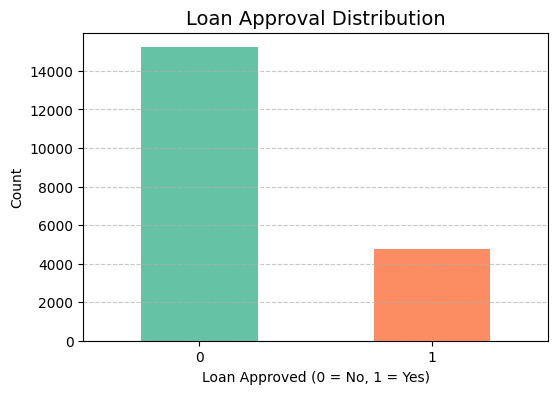

In [144]:
plt.figure(figsize=(6, 4))
df['LoanApproved'].value_counts().plot(kind='bar', color=['#66c2a5', '#fc8d62'])
plt.title('Loan Approval Distribution', fontsize=14)
plt.xlabel('Loan Approved (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

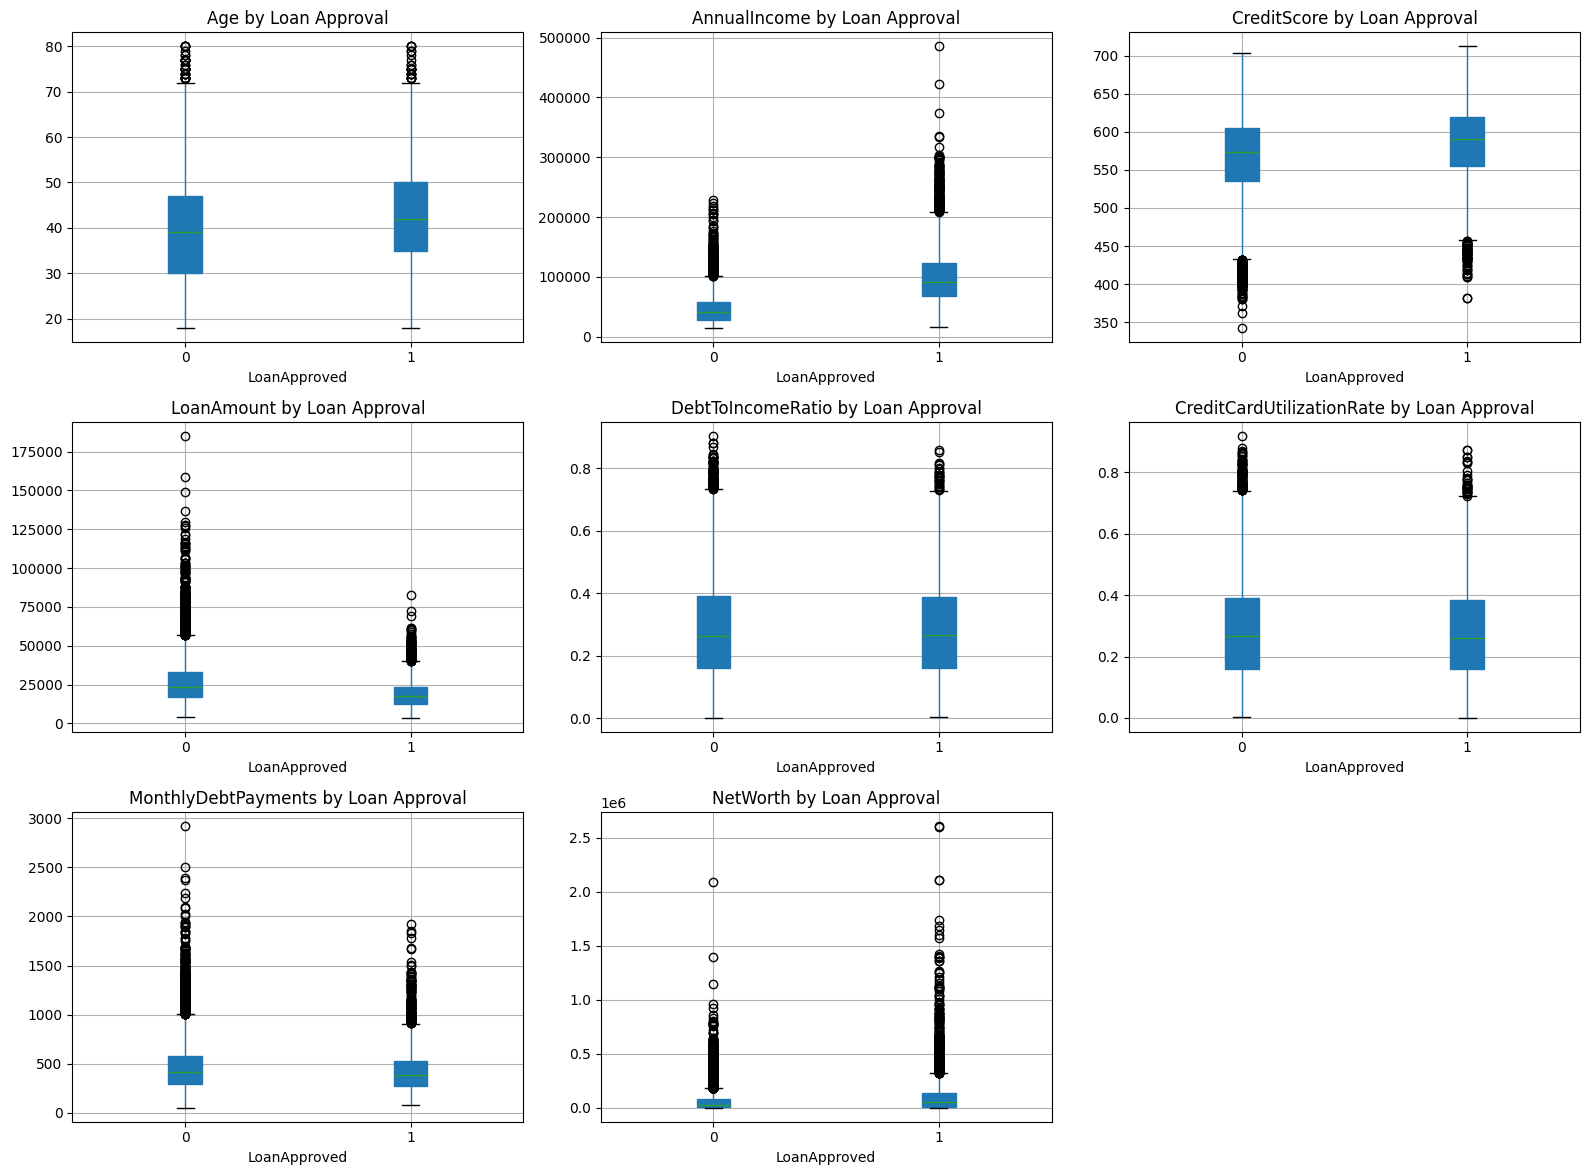

In [145]:
# Pick top 8 most relevant numeric features (avoid too many plots)
key_numeric = [
    'Age', 'AnnualIncome', 'CreditScore', 'LoanAmount',
    'DebtToIncomeRatio', 'CreditCardUtilizationRate',
    'MonthlyDebtPayments', 'NetWorth'
]

# Remove any not in your data
key_numeric = [col for col in key_numeric if col in df.columns]

n_cols = 3
n_rows = (len(key_numeric) + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))
for i, col in enumerate(key_numeric):
    plt.subplot(n_rows, n_cols, i + 1)
    df.boxplot(column=col, by='LoanApproved', ax=plt.gca(), patch_artist=True)
    plt.title(f'{col} by Loan Approval')
    plt.suptitle('')  # Remove default "Boxplot grouped by..."
plt.tight_layout()
plt.show()

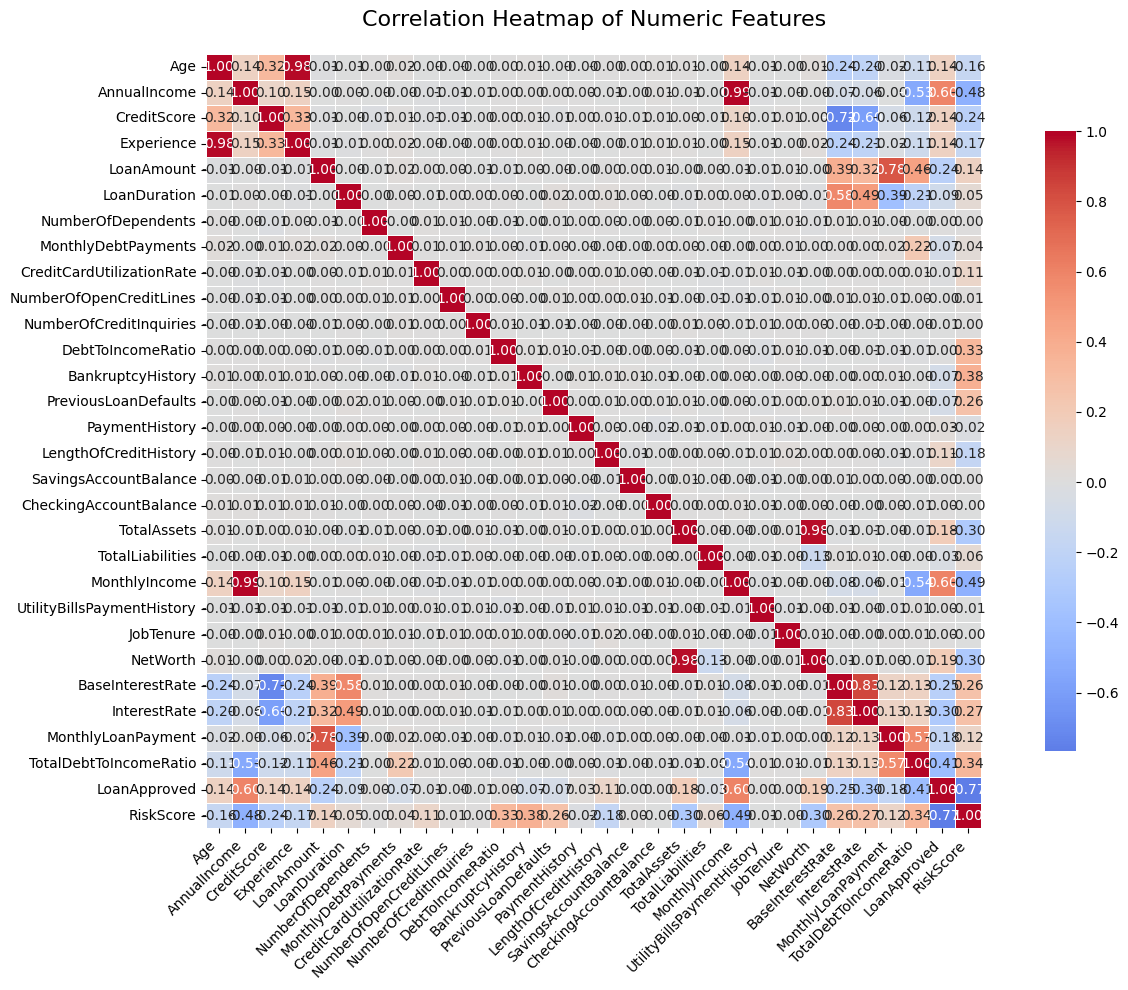

In [146]:
# Select all numeric columns (including LoanApproved and RiskScore)
numeric_data = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,                
    fmt='.2f',                 
    cmap='coolwarm',           
    center=0,                  
    square=True,               
    linewidths=0.5,            
    cbar_kws={"shrink": .8}    
)
plt.title('Correlation Heatmap of Numeric Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

scaling 


In [147]:
df[['EmploymentStatus'
    ]].value_counts()
df[['ApplicationDate'
    ]].value_counts()

ApplicationDate
2018-01-01         1
2054-07-01         1
2054-07-08         1
2054-07-07         1
2054-07-06         1
                  ..
2036-04-02         1
2036-04-01         1
2036-03-31         1
2036-03-30         1
2072-10-03         1
Name: count, Length: 20000, dtype: int64

In [148]:
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])

df['App_Year'] = df['ApplicationDate'].dt.year
df['App_Month'] = df['ApplicationDate'].dt.month


In [149]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,App_Year,App_Month
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,2018,1
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,2018,1
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,2018,1
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,2018,1
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,2018,1


In [150]:
df.drop(columns=['ApplicationDate'], inplace=True)


In [151]:
df.drop(columns=['App_Year'], inplace=True)

In [152]:
df["App_Month"].value_counts()

App_Month
1     1705
3     1705
5     1705
7     1705
8     1705
10    1677
12    1674
4     1650
6     1650
9     1650
11    1620
2     1554
Name: count, dtype: int64

In [153]:
num_col = df.select_dtypes(include=["number"]).columns
cat_col = df.select_dtypes(include=["object", "bool"]).columns


In [154]:
num_col = num_col.drop(["LoanApproved" ,"RiskScore"])

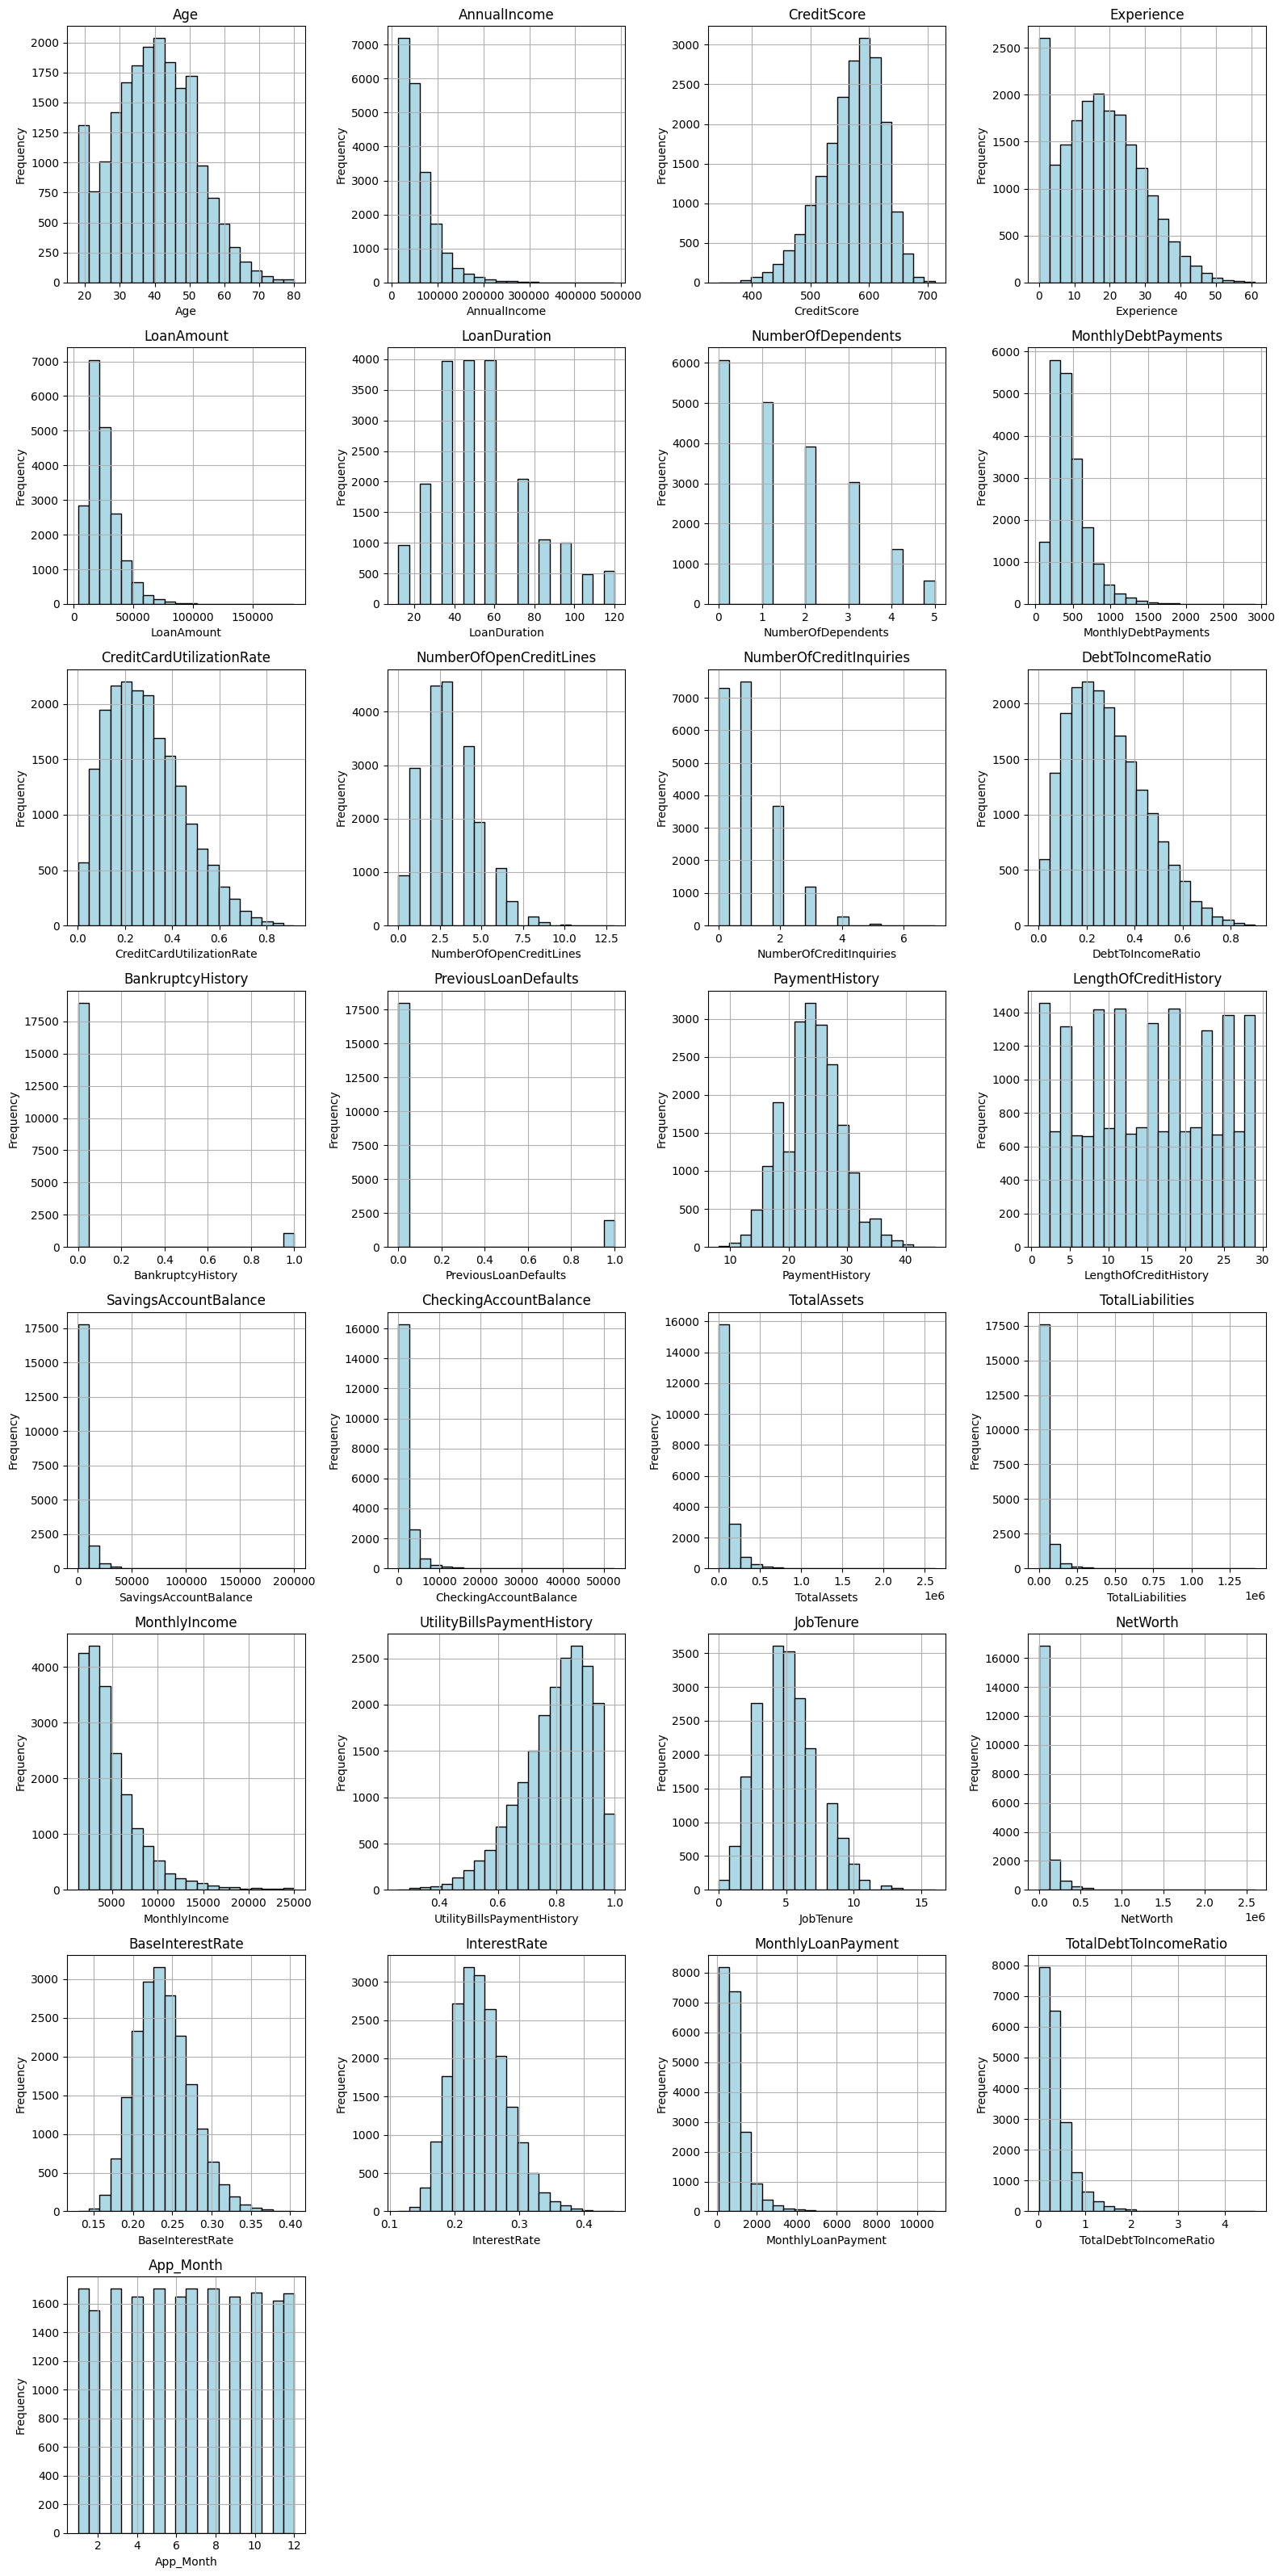

In [155]:
n_cols = 4
n_rows = (len(num_col) + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))
for i, col in enumerate(num_col):
    plt.subplot(n_rows, n_cols, i + 1)
    df[col].hist(bins=20, color='lightblue', edgecolor='black')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

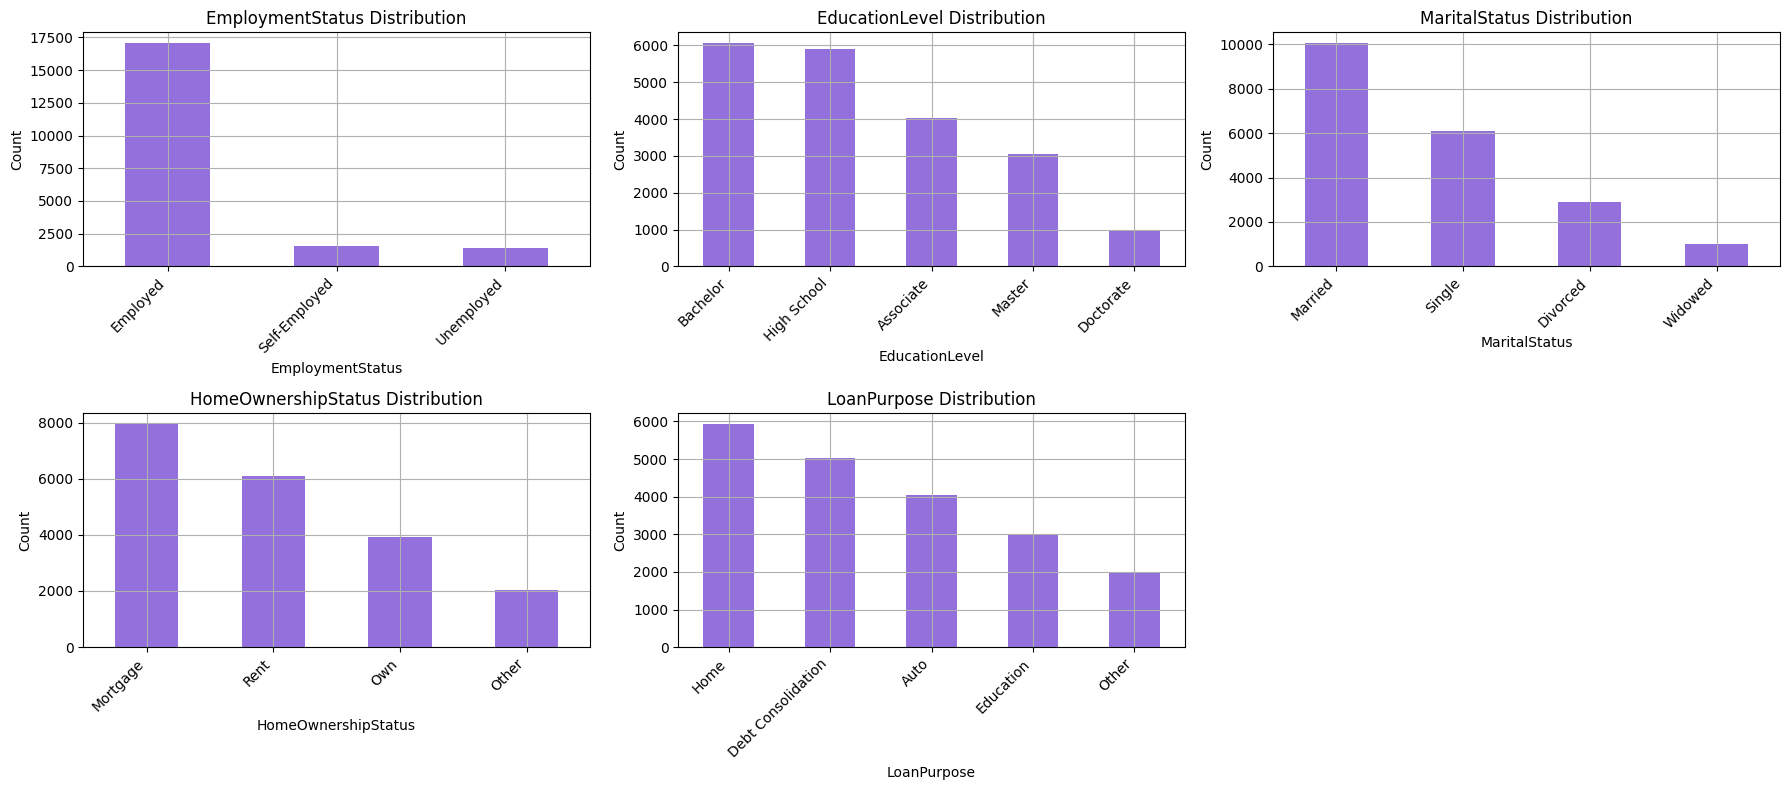

In [156]:
cat_col = [col for col in cat_col if col != 'ApplicationDate']

n_cols = 3
n_rows = (len(cat_col) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))
for i, col in enumerate(cat_col):
    plt.subplot(n_rows, n_cols, i + 1)
    value_counts = df[col].value_counts()
    value_counts.plot(kind='bar', color='mediumpurple')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True)
plt.tight_layout()
plt.show()

In [157]:
df[num_col].head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,App_Month
0,45,39948,617,22,13152,48,2,183,0.354418,1,...,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,1
1,38,39709,628,15,26045,48,1,496,0.087827,5,...,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,1
2,47,40724,570,26,17627,36,2,902,0.137414,2,...,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,1
3,58,69084,545,34,37898,96,1,755,0.267587,2,...,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,1
4,37,103264,594,17,9184,36,1,274,0.320535,0,...,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1


In [158]:
df['LoanPurpose'].value_counts()

LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64

In [159]:
for c in cat_col:
    print(df[[c]].value_counts())

EmploymentStatus
Employed            17036
Self-Employed        1573
Unemployed           1391
Name: count, dtype: int64
EducationLevel
Bachelor          6054
High School       5908
Associate         4034
Master            3050
Doctorate          954
Name: count, dtype: int64
MaritalStatus
Married          10041
Single            6078
Divorced          2882
Widowed            999
Name: count, dtype: int64
HomeOwnershipStatus
Mortgage               7939
Rent                   6087
Own                    3938
Other                  2036
Name: count, dtype: int64
LoanPurpose       
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


In [160]:
employment_order = ['Unemployed', 'Self-Employed', 'Employed']
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']


In [161]:
ordinal_cols = ['EmploymentStatus', 'EducationLevel']
onehot_cols = ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

In [162]:
num_transformer = Pipeline(steps=[
    ("impute ",SimpleImputer(strategy="mean")),
    ("scaler",StandardScaler()),
])

In [163]:
num_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [164]:
ordinal_transformer = Pipeline(steps=[
    ("impute ",SimpleImputer(strategy="most_frequent")),
    ("encode",OrdinalEncoder(categories=[employment_order, education_order]))
])

In [165]:
OneHot_transformer = Pipeline(steps=[
    ("impute ",SimpleImputer(strategy="most_frequent")),
    ("encode",OneHotEncoder(handle_unknown="ignore")),
])

In [166]:
preprocess = ColumnTransformer(
    transformers=[
        ("num",num_transformer,num_col),
        ("ordinal",ordinal_transformer,ordinal_cols),
        ("onehot",OneHot_transformer,onehot_cols),
    ]
)

In [167]:
preprocess_tree = ColumnTransformer(
    transformers=[
        ('num', num_tree, num_col),
        ('ordinal', ordinal_transformer, ordinal_cols),
        ('onehot', OneHot_transformer, onehot_cols)
    ]
)

In [168]:
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [169]:
X = df.drop(columns=['LoanApproved',"RiskScore"])
y = df['LoanApproved']

In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [171]:
kmean = KMeans(n_clusters=3, random_state=42)
X_train_scaled = preprocess.fit_transform(X_train)
kmean.fit(X_train_scaled)
kmeans_labels = kmean.labels_
print(kmeans_labels)


[0 1 1 ... 2 1 0]


In [172]:
# kmeanspipeline = Pipeline(steps=[
#     ("preprecoess",preprocess),
#     ("kmean",KMeans(n_clusters=3,random_state=42))
# ])

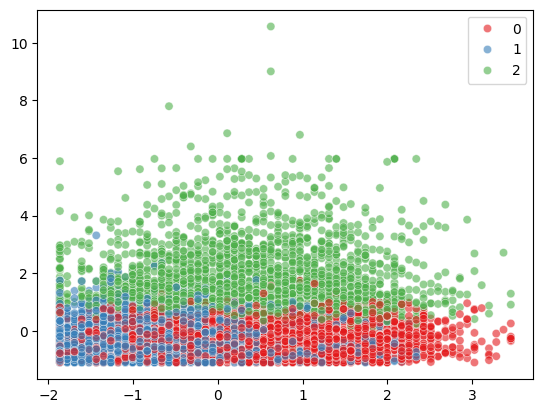

In [173]:
plt.Figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train_scaled[:, 0], 
    y=X_train_scaled[:, 1], 
    hue=kmeans_labels, 
    palette='Set1', 
    alpha=0.6
)
plt.show()

In [174]:
# Get cluster labels for training data
kmeans_labels = kmean.labels_

# Create a temporary analysis DataFrame
analysis_df = X_train.copy()
analysis_df['Cluster'] = kmeans_labels
analysis_df['LoanApproved'] = y_train.values

# Compute key stats per cluster
cluster_summary = analysis_df.groupby('Cluster').agg(
    Approval_Rate=('LoanApproved', 'mean'),
    Count=('LoanApproved', 'size'),
    Avg_CreditScore=('CreditScore', 'mean'),
    Avg_Income=('AnnualIncome', 'mean'),
    Avg_DTI=('DebtToIncomeRatio', 'mean')
).round(3)

# Sort by Approval Rate (highest = lowest risk)
cluster_summary = cluster_summary.sort_values('Approval_Rate', ascending=False)
print("Cluster Risk Profile (sorted by approval rate):")
print(cluster_summary)

Cluster Risk Profile (sorted by approval rate):
         Approval_Rate  Count  Avg_CreditScore  Avg_Income  Avg_DTI
Cluster                                                            
2                0.761   2704          585.095  126397.757    0.284
0                0.204   7397          596.404   47043.034    0.289
1                0.043   5899          534.296   43981.074    0.281


### Before Mapping 

| Cluster | Approval Rate | Income   | Credit Score | Risk Tier     | Business Meaning                                      |
|:-------:|:-------------:|:--------:|:------------:|:--------------|:------------------------------------------------------|
| **2**   | 76.1%         | $126k    | 585          | ✅ Low Risk   | High-income customers — easy approvals                |
| **0**   | 20.4%         | $47k     | 596          | ⚠️ Medium Risk| Moderate income, decent credit — borderline           |
| **1**   | 4.3%          | $44k     | 534          | ❌ High Risk  | Low income + poor credit — mostly rejected            |

In [175]:
remap = {2: 0, 0: 1, 1: 2}
train_clusters = np.array([remap[c] for c in kmean.labels_])

In [176]:
analysis_df_remapped = X_train.copy()
analysis_df_remapped['RiskTier'] = train_clusters  # 0=Low, 1=Medium, 2=High
analysis_df_remapped['LoanApproved'] = y_train.values

# Compute summary by new RiskTier
cluster_summary_remapped = analysis_df_remapped.groupby('RiskTier').agg(
    Approval_Rate=('LoanApproved', 'mean'),
    Count=('LoanApproved', 'size'),
    Avg_CreditScore=('CreditScore', 'mean'),
    Avg_Income=('AnnualIncome', 'mean'),
    Avg_DTI=('DebtToIncomeRatio', 'mean')
).round(3)

# Sort by RiskTier (0,1,2) — no need to sort by approval since it should decrease
cluster_summary_remapped = cluster_summary_remapped.sort_index()

print("\nCluster Profile AFTER Remapping (0=Low Risk, 1=Medium, 2=High Risk):")
print(cluster_summary_remapped)


Cluster Profile AFTER Remapping (0=Low Risk, 1=Medium, 2=High Risk):
          Approval_Rate  Count  Avg_CreditScore  Avg_Income  Avg_DTI
RiskTier                                                            
0                 0.761   2704          585.095  126397.757    0.284
1                 0.204   7397          596.404   47043.034    0.289
2                 0.043   5899          534.296   43981.074    0.281


### After Mapping

| Risk Tier | Approval Rate | Count | Avg Credit Score | Avg Income ($) | Avg DTI |
|:---------:|:-------------:|:-----:|:----------------:|:--------------:|:-------:|
| **0** (Low Risk)    | 76.1%         | 2,704 | 585.1            | 126,398        | 28.4%   |
| **1** (Medium Risk) | 20.4%         | 7,397 | 596.4            | 47,043         | 28.9%   |
| **2** (High Risk)   | 4.3%          | 5,899 | 534.3            | 43,981         | 28.1%   |

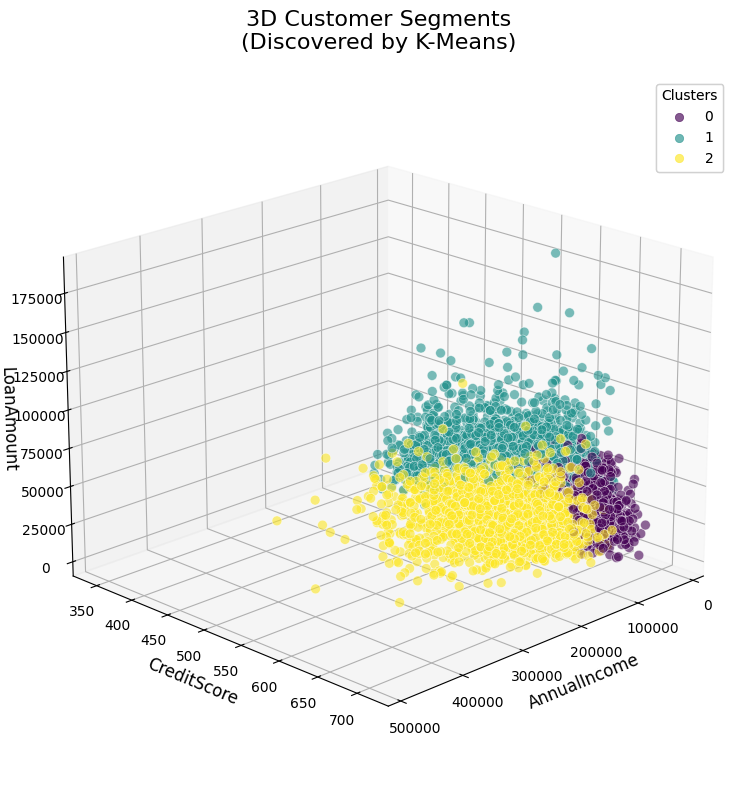

In [177]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Needed for 3D plotting

X_train_viz = X_train.copy()
X_train_viz['Cluster'] = kmean.labels_

# 3. Create the 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Define the axes (Choose 3 meaningful features for X, Y, Z)
# You can change these if you want to see other relationships
x_axis = 'AnnualIncome'
y_axis = 'CreditScore'
z_axis = 'LoanAmount'


scatter = ax.scatter(
    X_train_viz[x_axis], 
    X_train_viz[y_axis], 
    X_train_viz[z_axis], 
    c=X_train_viz['Cluster'], 
    cmap='viridis', 
    s=50,           # Size of dots
    alpha=0.6,      # Transparency
    edgecolors='w', # White borders
    linewidth=0.5
)

# 4. Styling the Chart
ax.set_xlabel(x_axis, fontsize=12)
ax.set_ylabel(y_axis, fontsize=12)
ax.set_zlabel(z_axis, fontsize=12)
ax.set_title('3D Customer Segments\n(Discovered by K-Means)', fontsize=16, pad=20)

# Add a legend
legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)

# Improve viewing angle (adjust these numbers to rotate)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

In [178]:
import plotly.express as px

# 1. Map cluster labels back to the original training data
# We do this so the axes show REAL values (Income, Score) 
# instead of scaled numbers (which are hard to read)
X_train_plot = X_train.copy()
X_train_plot['Cluster'] = kmean.labels_

# 2. Create the 3D Interactive Plot
fig = px.scatter_3d(
    X_train_plot,
    x='AnnualIncome',   # X-Axis
    y='CreditScore',    # Y-Axis
    z='LoanAmount',     # Z-Axis
    color='Cluster',    # Color by the groups found by KMeans
    title='🔍 3D Interactive Customer Segments',
    opacity=0.7,        # Make dots slightly transparent so you can see through them
    width=900,
    height=700,
    color_discrete_sequence=px.colors.qualitative.Vivid # Use nice distinct colors
)

# 3. Update labels to look professional
fig.update_layout(
    scene=dict(
        xaxis_title='Annual Income',
        yaxis_title='Credit Score',
        zaxis_title='Loan Amount'
    ),
    margin=dict(l=0, r=0, b=0, t=40) # Tight layout
)

fig.show()

In [179]:
def build_logistic():
    return Pipeline([
        ('preprocess', preprocess),
        ('classifier', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
        ))
    ])


In [180]:
def build_rf():
    return Pipeline([
        ('preprocess', preprocess_tree),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])

In [181]:
def build_xgb(y_cluster):
    n_pos = y_cluster.sum()
    n_neg = len(y_cluster) - n_pos
    scale_w = n_neg / n_pos if n_pos > 0 else 1.0

    return Pipeline([
        ('preprocess', preprocess_tree),
        ('classifier', XGBClassifier(
            scale_pos_weight=scale_w,
            n_estimators=300,
            learning_rate=0.05,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ])


In [182]:
def get_model_for_risk(risk_tier, y_cluster):
    if risk_tier == 0:
        print("Model call for risk tier 0")
        return build_logistic()
    elif risk_tier == 1:
        print("Model call for risk tier 1")
        return build_rf()
    else:
        print("Model call for risk tier 2")
        return build_xgb(y_cluster)


In [183]:
cluster_models = {}

for risk_tier in [0, 1, 2]:
    mask = (train_clusters == risk_tier)
    X_c = X_train.iloc[mask]
    y_c = y_train.iloc[mask]

    if len(X_c) < 50:
        continue

    model = get_model_for_risk(risk_tier, y_c)
    model.fit(X_c, y_c)

    cluster_models[risk_tier] = model
    

Model call for risk tier 0
Model call for risk tier 1
Model call for risk tier 2


In [184]:
X_test_scaled = preprocess.transform(X_test)
test_clusters_raw = kmean.predict(X_test_scaled)

# Apply same remap
test_clusters = np.array([remap[c] for c in test_clusters_raw])

In [185]:
def hybrid_predict(X, clusters, cluster_models):
    y_pred = np.zeros(len(X), dtype=int)

    for risk_tier in [0, 1, 2]:
        idx = np.where(clusters == risk_tier)[0]
        if len(idx) == 0:
            continue

        model = cluster_models[risk_tier]
        y_pred[idx] = model.predict(X.iloc[idx])

    return y_pred


In [186]:
y_pred_hybrid = hybrid_predict(
    X_test,
    test_clusters,
    cluster_models
)

print("HYBRID MODEL PERFORMANCE")
print(classification_report(y_test, y_pred_hybrid))
print("Accuracy:", accuracy_score(y_test, y_pred_hybrid))




HYBRID MODEL PERFORMANCE
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      3044
           1       0.93      0.69      0.79       956

    accuracy                           0.91      4000
   macro avg       0.92      0.84      0.87      4000
weighted avg       0.92      0.91      0.91      4000

Accuracy: 0.914


In [187]:

# ===========================================================
# 1. Evaluate GLOBAL models (you already trained them earlier?)
# If not, train them quickly now on full data
# ===========================================================

print("Training global baseline models...")

# Reuse your pipeline definitions
clf_rf_global = Pipeline(steps=[
    ('preprocess', preprocess_tree),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

clf_log_global = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

scale_pos_weight_global = (len(y_train) - sum(y_train)) / sum(y_train)
clf_xgb_global = Pipeline(steps=[
    ('preprocess', preprocess_tree),
    ('classifier', XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight_global,
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit global models
clf_rf_global.fit(X_train, y_train)
clf_log_global.fit(X_train, y_train)
clf_xgb_global.fit(X_train, y_train)

# Predictions
y_pred_rf = clf_rf_global.predict(X_test)
y_pred_log = clf_log_global.predict(X_test)
y_pred_xgb = clf_xgb_global.predict(X_test)

# ===========================================================
# 2. Build comparison table
# ===========================================================

from sklearn.metrics import precision_recall_fscore_support

def get_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return {
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1': round(f1, 4)
    }

results = []
results.append(get_metrics(y_test, y_pred_hybrid, 'Hybrid System'))
results.append(get_metrics(y_test, y_pred_log, 'Logistic (Global)'))
results.append(get_metrics(y_test, y_pred_rf, 'Random Forest (Global)'))
results.append(get_metrics(y_test, y_pred_xgb, 'XGBoost (Global)'))

results_df = pd.DataFrame(results)
print("\n🏆 MODEL COMPARISON (Higher is Better)")
print(results_df.to_string(index=False))

# Save to CSV (for report)
# results_df.to_csv('model_comparison.csv', index=False)

Training global baseline models...


c:\Users\pc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.

c:\Users\pc\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning:

[23:14:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.





🏆 MODEL COMPARISON (Higher is Better)
                 Model  Accuracy  Precision  Recall     F1
         Hybrid System    0.9140     0.9334  0.6893 0.7930
     Logistic (Global)    0.9597     0.8746  0.9707 0.9202
Random Forest (Global)    0.9320     0.9081  0.7960 0.8484
      XGBoost (Global)    0.9555     0.8791  0.9435 0.9102


C:\Users\pc\AppData\Local\Temp\ipykernel_27264\3238309592.py:50: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

c:\Users\pc\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



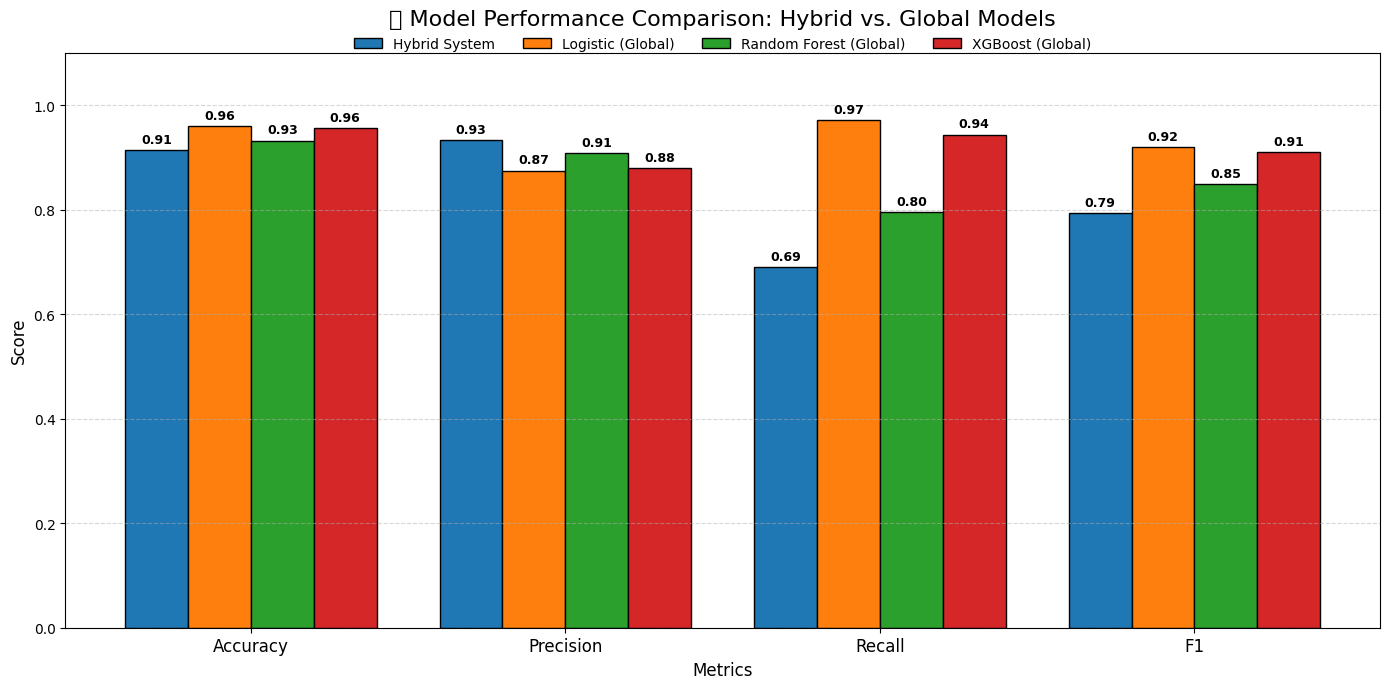

In [188]:
# ==========================================================
# 📊 VISUALIZATION: GROUPED BAR CHART COMPARISON
# ==========================================================

# 1. Prepare data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))  # Label locations
width = 0.2  # Width of the bars

# 2. Extract values for each model from the DataFrame
hybrid_vals = results_df[results_df['Model'] == 'Hybrid System'][metrics].values.flatten()
log_vals   = results_df[results_df['Model'] == 'Logistic (Global)'][metrics].values.flatten()
rf_vals    = results_df[results_df['Model'] == 'Random Forest (Global)'][metrics].values.flatten()
xgb_vals   = results_df[results_df['Model'] == 'XGBoost (Global)'][metrics].values.flatten()

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Create bars for each model
bars1 = ax.bar(x - 1.5*width, hybrid_vals, width, label='Hybrid System', color='#1f77b4', edgecolor='black')
bars2 = ax.bar(x - 0.5*width, log_vals, width, label='Logistic (Global)', color='#ff7f0e', edgecolor='black')
bars3 = ax.bar(x + 0.5*width, rf_vals, width, label='Random Forest (Global)', color='#2ca02c', edgecolor='black')
bars4 = ax.bar(x + 1.5*width, xgb_vals, width, label='XGBoost (Global)', color='#d62728', edgecolor='black')

# 4. Add Styling and Labels
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Metrics', fontsize=12)
ax.set_title('📊 Model Performance Comparison: Hybrid vs. Global Models', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)
ax.set_ylim(0, 1.1)  # Scores are between 0 and 1
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Add Value Labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

plt.tight_layout()
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_27264\3217239831.py:39: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\pc\AppData\Local\Temp\ipykernel_27264\3217239831.py:62: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\pc\AppData\Local\Temp\ipykernel_27264\3217239831.py:62: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




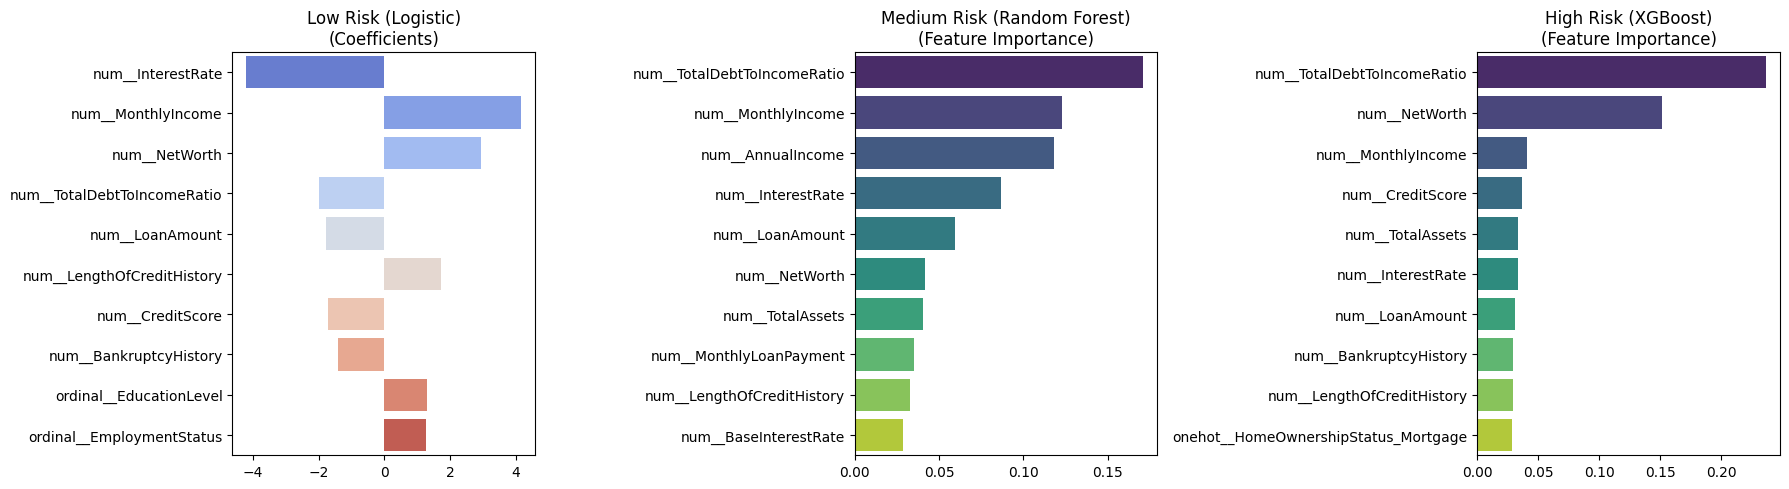

In [189]:
# ===========================================================
# 3. Extract feature names after preprocessing
# ===========================================================

def get_feature_names(preprocessor, num_col, ordinal_cols, onehot_cols):
    try:
        return preprocessor.get_feature_names_out()
    except AttributeError:
        # Fallback for older sklearn
        ohe = preprocessor.named_transformers_['onehot'].named_steps['encode']
        ohe_features = ohe.get_feature_names_out(onehot_cols)
        return list(num_col) + list(ordinal_cols) + list(ohe_features)

feature_names = get_feature_names(preprocess, num_col, ordinal_cols, onehot_cols)

# ===========================================================
# 4. Plot importance per risk tier
# ===========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

risk_tiers = [0, 1, 2]
titles = ['Low Risk (Logistic)', 'Medium Risk (Random Forest)', 'High Risk (XGBoost)']

for i, (tier, title) in enumerate(zip(risk_tiers, titles)):
    if tier not in cluster_models:
        continue
        
    model_pipe = cluster_models[tier]
    classifier = model_pipe.named_steps['classifier']
    
    if tier == 0:  # Logistic
        coefs = classifier.coef_[0]
        importance = np.abs(coefs)
        top_idx = np.argsort(importance)[-10:][::-1]  # top 10
        top_features = [feature_names[j] for j in top_idx]
        top_vals = coefs[top_idx]
        
        sns.barplot(x=top_vals, y=top_features, ax=axes[i], palette='coolwarm')
        axes[i].set_title(f'{title}\n(Coefficients)')
        
    else:  # RF or XGBoost
        if hasattr(classifier, 'feature_importances_'):
            importance = classifier.feature_importances_
        elif hasattr(classifier, 'get_booster'):
            # XGBoost gain
            importance = classifier.get_booster().get_score(importance_type='gain')
            # Convert dict to array matching feature_names
            imp_array = np.zeros(len(feature_names))
            for j, fname in enumerate(feature_names):
                key = fname.replace('<', '_').replace('>', '_')  # XGBoost sanitizes names
                if key in importance:
                    imp_array[j] = importance[key]
            importance = imp_array
        else:
            continue
            
        top_idx = np.argsort(importance)[-10:][::-1]
        top_features = [feature_names[j] for j in top_idx]
        top_vals = importance[top_idx]
        
        sns.barplot(x=top_vals, y=top_features, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{title}\n(Feature Importance)')

plt.tight_layout()
plt.savefig('feature_importance_by_risk_tier.png', dpi=150, bbox_inches='tight')
plt.show()

In [190]:
# Show how hybrid performs IN EACH RISK TIER
print("\n🔍 HYBRID MODEL PERFORMANCE BY RISK TIER")
for tier in [0, 1, 2]:
    mask = (test_clusters == tier)
    if mask.sum() == 0:
        continue
    print(f"\nRisk Tier {tier} (n={mask.sum()}):")
    print(classification_report(y_test[mask], y_pred_hybrid[mask]))


🔍 HYBRID MODEL PERFORMANCE BY RISK TIER

Risk Tier 0 (n=109):
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       1.00      0.97      0.99       108

    accuracy                           0.97       109
   macro avg       0.62      0.99      0.69       109
weighted avg       0.99      0.97      0.98       109


Risk Tier 1 (n=1418):
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       825
           1       0.95      0.71      0.81       593

    accuracy                           0.86      1418
   macro avg       0.89      0.84      0.85      1418
weighted avg       0.88      0.86      0.86      1418


Risk Tier 2 (n=2473):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      2218
           1       0.84      0.52      0.64       255

    accuracy                           0.94      2473
   macro avg       

C:\Users\pc\AppData\Local\Temp\ipykernel_27264\2925192603.py:71: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.

c:\Users\pc\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.



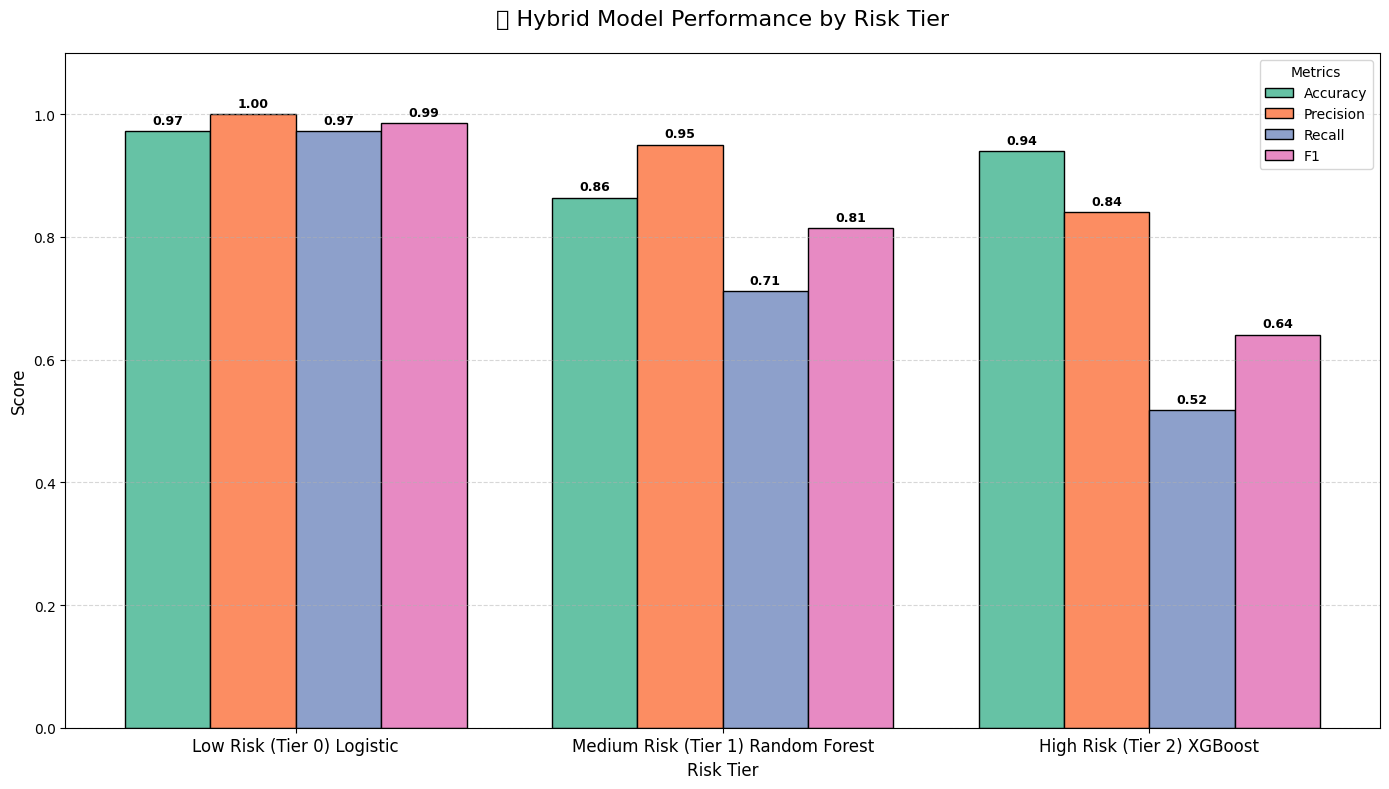

In [191]:
# ==========================================================
# 📊 VISUALIZATION: PERFORMANCE BY RISK TIER
# ==========================================================

metrics_to_track = ['Accuracy', 'Precision', 'Recall', 'F1']
tier_names = ['Low Risk (Tier 0) Logistic', 'Medium Risk (Tier 1) Random Forest', 'High Risk (Tier 2) XGBoost']
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'] # Distinct colors for metrics

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(tier_names))  # the label locations (Tier 0, 1, 2)
width = 0.2  # the width of the bars

# We will store bars in a list to add labels later
bars_list = []

for i, metric in enumerate(metrics_to_track):
    # Calculate metric value for each tier
    values = []
    for tier in [0, 1, 2]:
        mask = (test_clusters == tier)
        # Skip if tier doesn't exist in test set
        if mask.sum() == 0:
            values.append(0)
        else:
            y_t = y_test[mask]
            y_p = y_pred_hybrid[mask]
            
            # Calculate specific metric
            if metric == 'Accuracy':
                val = accuracy_score(y_t, y_p)
            elif metric == 'Precision':
                val = precision_score(y_t, y_p, zero_division=0)
            elif metric == 'Recall':
                val = recall_score(y_t, y_p, zero_division=0)
            elif metric == 'F1':
                val = f1_score(y_t, y_p, zero_division=0)
            values.append(val)
    
    # Plot the bars for this metric
    # Offset x position based on metric index (i)
    offset = (i - 1.5) * width 
    bars = ax.bar(x + offset, values, width, label=metric, color=colors[i], edgecolor='black')
    bars_list.append(bars)

# Add Styling
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Risk Tier', fontsize=12)
ax.set_title('🔍 Hybrid Model Performance by Risk Tier', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(tier_names, fontsize=12)
ax.legend(title="Metrics", loc='upper right')
ax.set_ylim(0, 1.1) # Scale 0-1
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add Value Labels on top of bars
def add_tier_labels(bars):
    for bar in bars:
        height = bar.get_height()
        # Only label if the bar has height > 0 to avoid clutter
        if height > 0.01: 
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

for bars in bars_list:
    add_tier_labels(bars)

plt.tight_layout()
plt.show()